In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats
from scipy.stats import norm
import pickle

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/')
from estimate_bayesian_fdr import *
from differential_splicing import *

In [2]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0209"

# List the directories in the main path
dirs = os.listdir(main_path)
# Which dirs have "NoCellType_Random" in them 
dirs = [d for d in dirs if "NoCellType_Random" in d]

In [53]:
# Choose which simulation directory to analyze 
dir_analyze=dirs[8]
print(dir_analyze)

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

analysis_20250209_161925_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_75
['random_init_38228_loss_curve.png', 'clustermap.png', 'losses.png', 'assignment_correlations.png', 'random_init_45111_loss_curve.png', 'est_deltapsi_vs_difference.png', 'random_init_5281_loss_curve.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'a_b_params.pkl', 'pi_df.csv', 'random_init_39232_loss_curve.png', 'albf_vs_difference.png', 'random_init_92698_loss_curve.png', 'random_init_27254_loss_curve.png', 'cell_type_psi_df.csv', 'final_results.csv', 'random_init_76362_loss_curve.png', 'ALBF_report.txt', 'umap.png.pdf', 'random_init_93740_loss_curve.png', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'random_init_34133_loss_curve.png', 'random_init_17851_loss_curve.png', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [54]:
sim_dir

'/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0209/analysis_20250209_161925_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_75'

In [55]:
# Extract PropNeg_0.5 from sim_dir 
prop_neg = sim_dir.split("_")[-14]
print(prop_neg)

0.1


In [56]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))
# get standard deviation of simulated usage in 0 and 1 PSI_df 
PSI_df["std"] = PSI_df[["0","1"]].std(axis=1)

# let's relabel the junctions based on the actual simulated difference and standard deviation 
# anything less than 0.1 is negative, anything greater than 0.1 is positive in difference 
# PSI_df["true_label"] = np.where(PSI_df["difference"] > 0.15, "positive", "negative")
# PSI_df["true_label"] = np.where(PSI_df["std"] < 0.075, "negative", PSI_df["true_label"])
print(PSI_df["true_label"].value_counts())

# Load learned pis vector 
pis = pd.read_csv(os.path.join(sim_dir, "pi_df.csv"))
pis = pis.sort_values(by=['Factor'])
pis = pis["pi"].values

true_label
positive    14307
negative     1587
Name: count, dtype: int64


In [57]:
# open a, b prior pickle file a_b_params.pkl 
with open(os.path.join(sim_dir, "a_b_params.pkl"), 'rb') as f:
    a_b_params = pickle.load(f)

In [58]:
a = a_b_params['a']
b = a_b_params['b']

print(f"The latent variables a and b for prior on PSI are {a} and {b}")
print(f"This corresponds to a prior mean of {a/(a+b)}")

The latent variables a and b for prior on PSI are [0.7702236  1.5400264  0.70862794 ... 1.0102262  0.38061324 0.7308912 ] and [0.81024945 1.2728903  1.3493171  ... 1.5497392  1.0175982  1.0412784 ]
This corresponds to a prior mean of [0.48733738 0.5474838  0.34433764 ... 0.39462492 0.27221438 0.41242737]


In [59]:
print(f"The learned pi values are {pis}")

The learned pi values are [0.49716157 0.5028384 ]


In [60]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# remove true_label from albf_scores 
albf_scores = albf_scores.drop(columns=["true_label", "true_label_binary", "predicted_label"])

# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})

In [61]:
albf_scores = albf_scores.merge(PSI_df[["junction_id_index", "true_label", "std"]], on="junction_id_index")
albf_scores.true_label.value_counts()

true_label
positive    14307
negative     1587
Name: count, dtype: int64

In [62]:
# calcualte pearson and spearman correlation between ALBF and simulated difference
pearson_corr = stats.pearsonr(albf_scores["ALBF"], albf_scores["difference"])
spearman_corr = stats.spearmanr(albf_scores["ALBF"], albf_scores["difference"])

print(f"Pearson correlation between ALBF and simulated difference: {pearson_corr}")
print(f"Spearman correlation between ALBF and simulated difference: {spearman_corr}")

Pearson correlation between ALBF and simulated difference: PearsonRResult(statistic=0.5799617532872146, pvalue=0.0)
Spearman correlation between ALBF and simulated difference: SignificanceResult(statistic=0.8205160427594392, pvalue=0.0)


<Axes: >

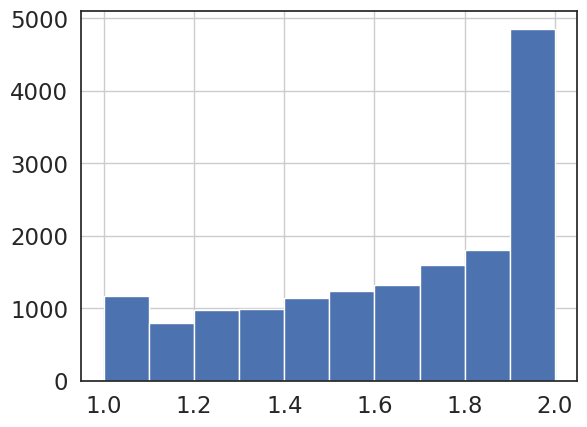

In [63]:
albf_scores.perplexity.hist()

In [64]:
# do junctions with higher difference simulated have lower perplexity?
# calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(albf_scores["perplexity"], albf_scores["difference"])
spearman_corr = stats.spearmanr(albf_scores["perplexity"], albf_scores["difference"])

print(f"Pearson correlation between perplexity and simulated difference: {pearson_corr}")
print(f"Spearman correlation between perplexity and simulated difference: {spearman_corr}")

Pearson correlation between perplexity and simulated difference: PearsonRResult(statistic=-0.6659483118469265, pvalue=0.0)
Spearman correlation between perplexity and simulated difference: SignificanceResult(statistic=-0.7721635116139707, pvalue=0.0)


In [65]:
# The priors a and b are 0.5559861063957214 and 1.0212149620056152
# visualize beta distribution with a=0.56 and b=1.02

x = np.linspace(0, 1, 5000)
y = stats.beta.pdf(x, a, b)
plt.plot(x, y)

ValueError: operands could not be broadcast together with shapes (15894,) (5000,) 

In [66]:
def compute_fw_dss(albf_scores, pi_k, a_prior, b_prior):
    """
    Compute Factor-Weighted Differential Splicing Score (FW-DSS) for each junction.
    
    Parameters:
    - albf_scores (pd.DataFrame): DataFrame containing 'mu_k' and 'var_k' for each factor.
    - pi_k (np.array): Factor contributions (size K).
    - a_prior (float): Beta prior shape parameter a.
    - b_prior (float): Beta prior shape parameter b.
    
    Returns:
    - pd.Series: FW-DSS scores for each junction.
    """
    # Extract number of factors (K)
    K = len(pi_k)
    
    # Extract mu and variance columns dynamically
    mu_cols = [f"mu_{k}" for k in range(K)]
    var_cols = [f"loc_{k}" for k in range(K)]  # Assuming loc_k represents variance
    
    # Convert to numpy arrays for efficient computation
    mu_jk = albf_scores[mu_cols].to_numpy()  # (J x K)
    var_jk = albf_scores[var_cols].to_numpy()  # (J x K)
    
    # Compute weighted mean for each junction (J, )
    mu_avg_j = np.dot(mu_jk, pi_k)
    
    # Compute FW-DSS:
    # (1) Weighted variance term: How much junction varies across factors
    weighted_variance = np.sum(pi_k * (mu_jk - mu_avg_j[:, None])**2, axis=1)
    
    # (2) Weighted uncertainty: Variance term weighted by factor contributions
    weighted_uncertainty = np.sum(pi_k * var_jk, axis=1)
    
    # Combine terms
    fw_dss = weighted_variance + weighted_uncertainty

    # Normalize by prior a + b (optional)
    fw_dss /= (a_prior + b_prior)
    
    # Return as pandas Series
    return pd.Series(fw_dss, index=albf_scores.index, name="FW-DSS")

In [67]:
def compute_confidence_weighted_fw_dss(albf_scores, pi_k):
    """
    Compute Confidence-Weighted Factor-Weighted Differential Splicing Score (FW-DSS) 
    without incorrectly using a, b as priors on z_j.

    Parameters:
    - albf_scores (pd.DataFrame): DataFrame containing 'mu_k' and 'var_k' for each factor.
    - pi_k (np.array): Factor contributions (size K).

    Returns:
    - pd.Series: FW-DSS scores for each junction.
    """
    # Number of factors (K)
    K = len(pi_k)
    
    # Extract column names dynamically
    mu_cols = [f"mu_{k}" for k in range(K)]
    var_cols = [f"loc_{k}" for k in range(K)]  # Assuming 'loc_k' represents posterior variance

    # Convert to numpy arrays for efficient computation
    mu_jk = albf_scores[mu_cols].to_numpy()  # (J x K) matrix of mean junction usage per factor
    var_jk = albf_scores[var_cols].to_numpy()  # (J x K) matrix of variances

    # Compute population-wide mean for each junction
    mu_pop_j = np.dot(mu_jk, pi_k)  # Weighted mean across factors

    # Compute Confidence-Weighted FW-DSS:
    confidence_weighted_variance = np.sum(pi_k * ((mu_jk - mu_pop_j[:, None])**2) / (1 + var_jk), axis=1)

    # Return as pandas Series
    return pd.Series(confidence_weighted_variance, index=albf_scores.index, name="FW-DSS")


In [68]:
albf_scores["FW-DSS"] = compute_fw_dss(albf_scores, pis, a, b)
albf_scores["FW-DSS-wvar"] = compute_confidence_weighted_fw_dss(albf_scores, pis)

In [69]:
albf_scores

,latent_psi_1,latent_psi_2,entropy,perplexity,junction_id_index,ALBF,difference,Cluster,delta_est,mu_0,loc_0,mu_1,loc_1,true_label,std,FW-DSS,FW-DSS-wvar
0,0.131507,0.171321,0.684480,1.982740,0,0.705399,0.038831,35178,0.039814,-1.885290,0.016154,-1.575338,0.017936,positive,0.027458,0.025984,0.023614
1,0.739124,0.667128,0.691836,1.997379,1,1.203554,0.077662,35178,0.071996,1.037279,0.012261,0.694558,0.012136,positive,0.054915,0.014775,0.029009
2,0.133094,0.172929,0.684651,1.983080,2,0.735374,0.038831,35178,0.039835,-1.872270,0.019004,-1.568778,0.012706,positive,0.027458,0.018884,0.022666
3,0.029289,0.427946,0.237987,1.268692,3,18.289032,0.391484,37286,0.398657,-3.569758,0.109983,-0.306768,0.035730,positive,0.276821,1.193975,2.483424
4,0.948514,0.156684,0.408164,1.504055,4,43.157814,0.782967,37286,0.791829,2.920796,0.072431,-1.692616,0.050754,positive,0.553641,2.771660,5.012250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15889,0.561990,0.131767,0.486125,1.626003,15889,12.758548,0.408389,62094,0.430223,0.254321,0.039658,-1.880035,0.049681,positive,0.288775,0.600563,1.090191
15890,0.227119,0.440814,0.641057,1.898486,15890,3.412427,0.204194,62094,0.213695,-1.226891,0.038128,-0.252833,0.031389,positive,0.144387,0.121321,0.229220
15891,0.492535,0.112158,0.479601,1.615430,15891,7.135211,0.366684,62095,0.380377,-0.023519,0.043227,-2.041399,0.100635,positive,0.259284,0.425795,0.950446
15892,0.029682,0.785134,0.156419,1.169316,15892,20.184336,0.733367,62095,0.755453,-3.753212,0.262054,1.296208,0.054752,positive,0.518569,4.671518,5.543956


In [70]:
# let's set up a dictionary to keep track of the results for tp, fp, tn, fn, fdr, fnr at each percentile along with what the ALBF cutoff is
em_results = {}

em = EMDifferentialSplicing(albf_scores["FW-DSS-wvar"], initial_p=0.1, max_iter=200)
results = em.fit()

Initial Statistics:
Original ALBF range: [0.00, 135.57]
b_j range: [0.5000, 1.0000]

Iteration 1:
p: 0.232641
log likelihood: -12635.563421
q_s1 range: [0.100000, 1.000000]

Iteration 2:
p: 0.375540
log likelihood: -9985.995263
q_s1 range: [0.232641, 1.000000]

Iteration 3:
p: 0.507285
log likelihood: -8489.824840
q_s1 range: [0.375540, 1.000000]

Iteration 4:
p: 0.619239
log likelihood: -7571.297776
q_s1 range: [0.507285, 1.000000]

Iteration 5:
p: 0.709930
log likelihood: -6976.071335
q_s1 range: [0.619239, 1.000000]

Iteration 6:
p: 0.781214
log likelihood: -6575.994993
q_s1 range: [0.709930, 1.000000]

Iteration 7:
p: 0.836141
log likelihood: -6300.184345
q_s1 range: [0.781214, 1.000000]

Iteration 8:
p: 0.877896
log likelihood: -6106.612301
q_s1 range: [0.836141, 1.000000]

Iteration 9:
p: 0.900000
log likelihood: -5969.014013
q_s1 range: [0.877896, 1.000000]

Iteration 10:
p: 0.900000
log likelihood: -5899.207745
q_s1 range: [0.900000, 1.000000]

Iteration 11:
p: 0.900000
log lik

In [71]:
albf_scores["posterior_probs"] = results["posterior_probs"]

In [72]:
# what's the range of FW-DSS scores for positive and negative labels?
print(f"Range of FW-DSS scores for positive labels: {albf_scores[albf_scores['true_label'] == 'positive']['FW-DSS-wvar'].min()} - {albf_scores[albf_scores['true_label'] == 'positive']['FW-DSS-wvar'].max()}")
print(f"Range of FW-DSS scores for negative labels: {albf_scores[albf_scores['true_label'] == 'negative']['FW-DSS-wvar'].min()} - {albf_scores[albf_scores['true_label'] == 'negative']['FW-DSS-wvar'].max()}")

Range of FW-DSS scores for positive labels: 8.376030931883064e-08 - 135.568485498072
Range of FW-DSS scores for negative labels: 7.993087501300775e-11 - 12.388323678782807


Pearson correlation between FW-DSS and simulated difference for positive labels: PearsonRResult(statistic=0.5775916820290536, pvalue=0.0)
Spearman correlation between FW-DSS and simulated difference for positive labels: SignificanceResult(statistic=0.8742184873896193, pvalue=0.0)


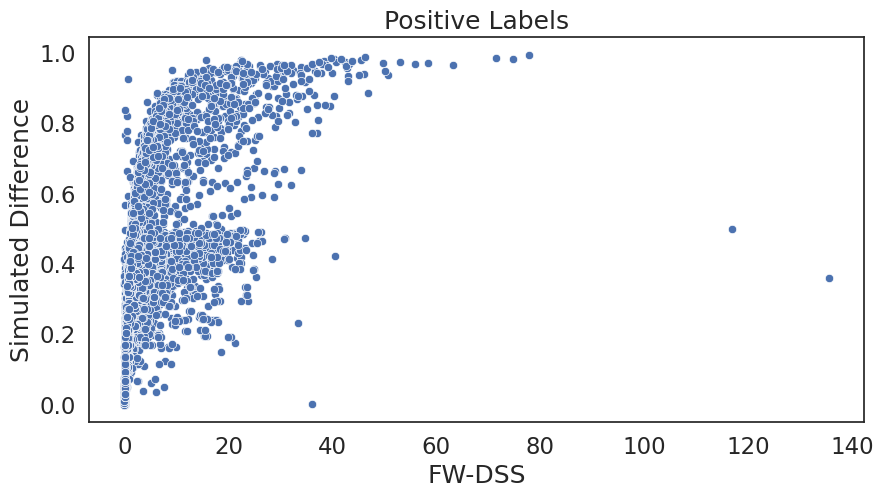

In [73]:
# what's the correlation between FW-DSS and simulated difference within negative and positive labels?
neg_juncs = albf_scores[albf_scores["true_label"] == "negative"]
pos_juncs = albf_scores[albf_scores["true_label"] == "positive"]

# plot correlation between FW-DSS and simulated difference for negative labels
plt.figure(figsize=(10, 5))
sns.scatterplot(x="FW-DSS-wvar", y="difference", data=pos_juncs)
plt.xlabel("FW-DSS")
plt.ylabel("Simulated Difference")
plt.title("Positive Labels")
# calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(pos_juncs["FW-DSS-wvar"], pos_juncs["difference"])
spearman_corr = stats.spearmanr(pos_juncs["FW-DSS-wvar"], pos_juncs["difference"])
print(f"Pearson correlation between FW-DSS and simulated difference for positive labels: {pearson_corr}")
print(f"Spearman correlation between FW-DSS and simulated difference for positive labels: {spearman_corr}")

In [74]:
# let's use negative labels distribution to calcualte cutoffs on FW-DSS
# calculate cutoffs for different FDR levels
fdr_levels = [0.01, 0.05, 0.1]
fdr_cutoffs = {}
for fdr_level in fdr_levels:
    # Get negative label estimate at this 1-FDR level
    fdr_cutoff = neg_juncs["FW-DSS-wvar"].quantile(1 - fdr_level)
    fdr_cutoffs[fdr_level] = fdr_cutoff

In [75]:
fdr_cutoffs

{0.01: 0.39889724923576975,
 0.05: 0.023447466617498997,
 0.1: 0.005946470385755954}

In [76]:
# how many junctions are above the cutoffs for different FDR levels? let's do 0.05 first 
albf_scores["fdr_0.01"] = albf_scores["FW-DSS"] > fdr_cutoffs[0.01]
albf_scores["fdr_0.05"] = albf_scores["FW-DSS"] > fdr_cutoffs[0.05]
albf_scores["fdr_0.1"] = albf_scores["FW-DSS"] > fdr_cutoffs[0.1]

In [77]:
# compare true labels with FDR labels 
# calculate confusion matrix for different FDR levels
confusion_01 = pd.crosstab(albf_scores["true_label"], albf_scores["fdr_0.01"])
confusion_05 = pd.crosstab(albf_scores["true_label"], albf_scores["fdr_0.05"])
confusion_1 = pd.crosstab(albf_scores["true_label"], albf_scores["fdr_0.1"])

# Get TP, FP, TN, FN for different FDR levels
tp_01 = confusion_01.loc["positive", True]
fp_01 = confusion_01.loc["negative", True]
tn_01 = confusion_01.loc["negative", False]
fn_01 = confusion_01.loc["positive", False]

tp_05 = confusion_05.loc["positive", True]
fp_05 = confusion_05.loc["negative", True]
tn_05 = confusion_05.loc["negative", False]
fn_05 = confusion_05.loc["positive", False]

tp_1 = confusion_1.loc["positive", True]
fp_1 = confusion_1.loc["negative", True]
tn_1 = confusion_1.loc["negative", False]
fn_1 = confusion_1.loc["positive", False]

# calculate FDR and FNR for different FDR levels
fdr_01 = fp_01 / (tp_01 + fp_01)
fnr_01 = fn_01 / (tp_01 + fn_01)

fdr_05 = fp_05 / (tp_05 + fp_05)
fnr_05 = fn_05 / (tp_05 + fn_05)

fdr_1 = fp_1 / (tp_1 + fp_1)
fnr_1 = fn_1 / (tp_1 + fn_1)

# save results in a dictionary
em_results["0.01"] = {"TP": tp_01, "FP": fp_01, "TN": tn_01, "FN": fn_01, "FDR": fdr_01, "FNR": fnr_01, "FW-DSS_cutoff": fdr_cutoffs[0.01]}
em_results["0.05"] = {"TP": tp_05, "FP": fp_05, "TN": tn_05, "FN": fn_05, "FDR": fdr_05, "FNR": fnr_05, "FW-DSS_cutoff": fdr_cutoffs[0.05]}
em_results["0.1"] = {"TP": tp_1, "FP": fp_1, "TN": tn_1, "FN": fn_1, "FDR": fdr_1, "FNR": fnr_1, "FW-DSS_cutoff": fdr_cutoffs[0.1]}

# convert results to a DataFrame
em_results_df = pd.DataFrame.from_dict(em_results, orient="index")

In [78]:
albf_scores

,latent_psi_1,latent_psi_2,entropy,perplexity,junction_id_index,ALBF,difference,Cluster,delta_est,mu_0,...,mu_1,loc_1,true_label,std,FW-DSS,FW-DSS-wvar,posterior_probs,fdr_0.01,fdr_0.05,fdr_0.1
0,0.131507,0.171321,0.684480,1.982740,0,0.705399,0.038831,35178,0.039814,-1.885290,...,-1.575338,0.017936,positive,0.027458,0.025984,0.023614,0.902105,False,True,True
1,0.739124,0.667128,0.691836,1.997379,1,1.203554,0.077662,35178,0.071996,1.037279,...,0.694558,0.012136,positive,0.054915,0.014775,0.029009,0.902581,False,False,True
2,0.133094,0.172929,0.684651,1.983080,2,0.735374,0.038831,35178,0.039835,-1.872270,...,-1.568778,0.012706,positive,0.027458,0.018884,0.022666,0.902022,False,False,True
3,0.029289,0.427946,0.237987,1.268692,3,18.289032,0.391484,37286,0.398657,-3.569758,...,-0.306768,0.035730,positive,0.276821,1.193975,2.483424,0.990812,True,True,True
4,0.948514,0.156684,0.408164,1.504055,4,43.157814,0.782967,37286,0.791829,2.920796,...,-1.692616,0.050754,positive,0.553641,2.771660,5.012250,0.999261,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15889,0.561990,0.131767,0.486125,1.626003,15889,12.758548,0.408389,62094,0.430223,0.254321,...,-1.880035,0.049681,positive,0.288775,0.600563,1.090191,0.963995,True,True,True
15890,0.227119,0.440814,0.641057,1.898486,15890,3.412427,0.204194,62094,0.213695,-1.226891,...,-0.252833,0.031389,positive,0.144387,0.121321,0.229220,0.918822,False,True,True
15891,0.492535,0.112158,0.479601,1.615430,15891,7.135211,0.366684,62095,0.380377,-0.023519,...,-2.041399,0.100635,positive,0.259284,0.425795,0.950446,0.958817,True,True,True
15892,0.029682,0.785134,0.156419,1.169316,15892,20.184336,0.733367,62095,0.755453,-3.753212,...,1.296208,0.054752,positive,0.518569,4.671518,5.543956,0.999566,True,True,True


The means are: tensor([ 0.2543, -1.8800], dtype=torch.float64)
The variances are: tensor([0.0397, 0.0497], dtype=torch.float64)
The combined mean is: -0.6991226673126221
The combined variance is: 0.044135645031929016
The means are: [0.25432125, -1.8800352, -0.6991226673126221]
The variances are: [0.039658498, 0.049680922, 0.044135645031929016]
The mean of the sampled PSI values is: 0.5583427106439793
The mean of the sampled PSI values is: 0.12182216017847994
The mean of the sampled PSI values is: 0.3104967000642181


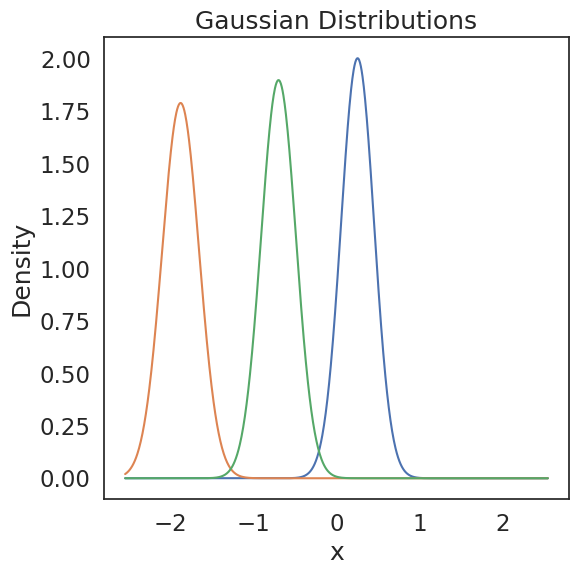

In [79]:
plot_junc_dists(albf_scores, 15889, pis)

In [80]:
albf_scores.true_label.value_counts()

true_label
positive    14307
negative     1587
Name: count, dtype: int64

<Axes: xlabel='FW-DSS-wvar', ylabel='Count'>

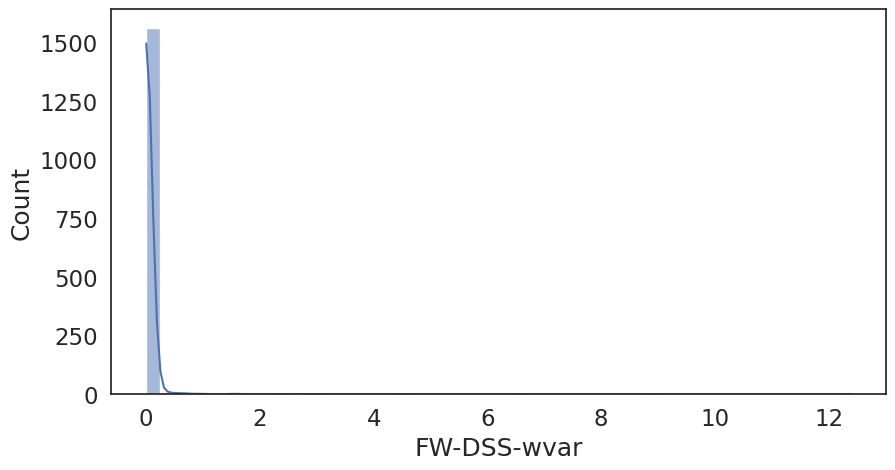

In [81]:
# plot distribution of FW-DSS scores negative labels
neg_juncs = albf_scores[albf_scores["true_label"] == "negative"]
neg_juncs.sort_values(by="FW-DSS-wvar", ascending=False)
plt.figure(figsize=(10, 5))
sns.histplot(neg_juncs["FW-DSS-wvar"], bins=50, kde=True)

<Axes: xlabel='latent_psi_1', ylabel='0'>

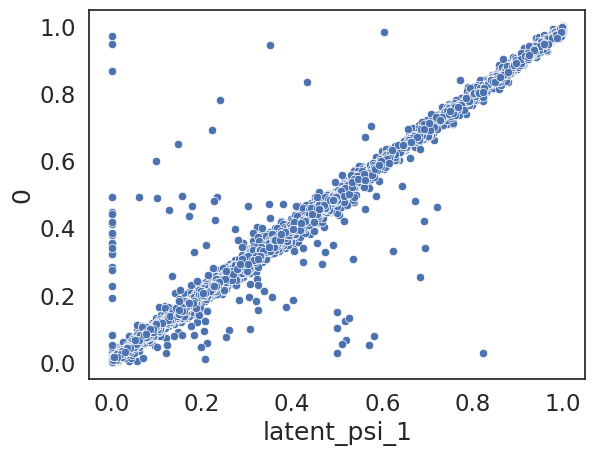

In [82]:
# plot latent_psi_1 from albf_scores vs "0" from PSI_df
sns.scatterplot(x=albf_scores["latent_psi_1"], y=PSI_df["0"])

<Axes: xlabel='latent_psi_2', ylabel='1'>

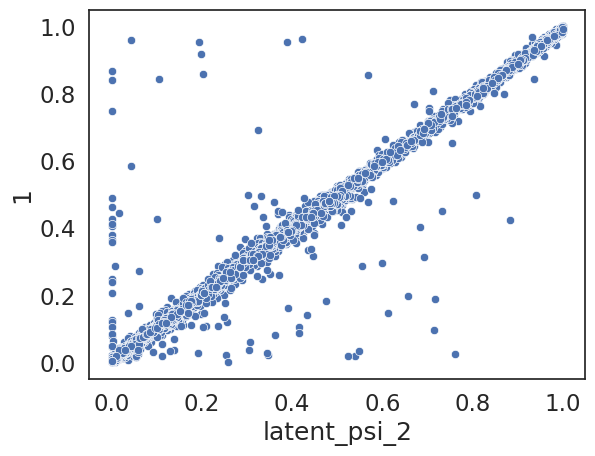

In [83]:
sns.scatterplot(x=albf_scores["latent_psi_2"], y=PSI_df["1"])

In [84]:
albf_scores.sort_values(by="FW-DSS-wvar", ascending=False)

,latent_psi_1,latent_psi_2,entropy,perplexity,junction_id_index,ALBF,difference,Cluster,delta_est,mu_0,...,mu_1,loc_1,true_label,std,FW-DSS,FW-DSS-wvar,posterior_probs,fdr_0.01,fdr_0.05,fdr_0.1
8792,1.163564e-10,0.052659,4.403901e-08,1.000000,8792,38.251290,0.360927,8551,0.052659,-37.704740,...,-2.809957,0.281947,positive,0.255214,236.436626,1.355685e+02,1.0,True,True,True
9691,5.956594e-08,0.851857,1.211675e-06,1.000001,9691,28.419704,0.498433,12369,0.851857,-28.335424,...,1.745830,0.077554,positive,0.352445,321.906673,1.169086e+02,1.0,True,True,True
11050,9.999550e-01,0.000039,4.303415e-04,1.000430,11050,148.284740,0.994018,19721,0.999916,10.288156,...,-10.216063,0.294563,positive,0.702877,255.432289,7.775023e+01,1.0,True,True,True
9583,8.472735e-05,0.999979,8.790593e-04,1.000879,9583,125.887146,0.983290,9632,0.999894,-9.665070,...,10.789018,0.267370,positive,0.695291,175.368237,7.469736e+01,1.0,True,True,True
8869,9.999627e-01,0.000062,6.586073e-04,1.000659,8869,119.465000,0.985433,4912,0.999901,10.132030,...,-10.082828,0.447993,positive,0.696806,161.463216,7.157486e+01,1.0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14457,2.812452e-02,0.027510,6.930863e-01,1.999878,14457,0.000229,0.000000,33917,0.000614,-3.553924,...,-3.553829,0.024062,negative,0.000000,0.010554,2.173781e-09,0.9,False,False,True
3044,8.239347e-01,0.824236,6.931471e-01,2.000000,3044,0.001419,0.000000,46723,0.000302,1.544525,...,1.544432,0.015150,negative,0.000000,0.005873,2.141335e-09,0.9,False,False,False
1059,9.128788e-02,0.090086,6.931253e-01,1.999956,1059,0.000000,0.000000,39540,0.001202,-2.294346,...,-2.294436,0.038191,negative,0.000000,0.017106,1.954439e-09,0.9,False,False,True
15301,1.838486e-01,0.180403,6.931025e-01,1.999911,15301,0.001471,0.000000,32736,0.003446,-1.502116,...,-1.502047,0.057096,negative,0.000000,0.015884,1.136887e-09,0.9,False,False,True


Spearman correlation between FW-DSS and ALBF: SignificanceResult(statistic=0.7783773152034319, pvalue=0.0)


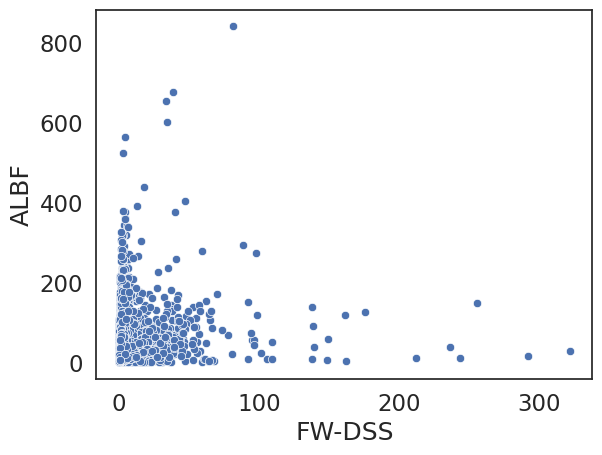

In [85]:
sns.scatterplot(x=albf_scores["FW-DSS"], y=albf_scores["ALBF"])
# get spearman correlation between FW-DSS and ALBF
spearman_corr = stats.spearmanr(albf_scores["FW-DSS"], albf_scores["ALBF"])
print(f"Spearman correlation between FW-DSS and ALBF: {spearman_corr}")

Spearman correlation between FW-DSS-wvar and ALBF: SignificanceResult(statistic=0.829409035095875, pvalue=0.0)


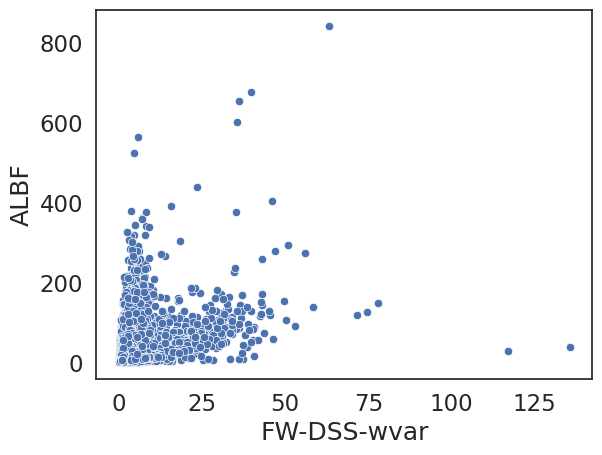

In [86]:
sns.scatterplot(x=albf_scores["FW-DSS-wvar"], y=albf_scores["ALBF"])
# get spearman correlation between FW-DSS and ALBF
spearman_corr = stats.spearmanr(albf_scores["FW-DSS-wvar"], albf_scores["ALBF"])
print(f"Spearman correlation between FW-DSS-wvar and ALBF: {spearman_corr}")

Spearman correlation between FW-DSS and FW-DSS-wvar: SignificanceResult(statistic=0.9797850191878799, pvalue=0.0)


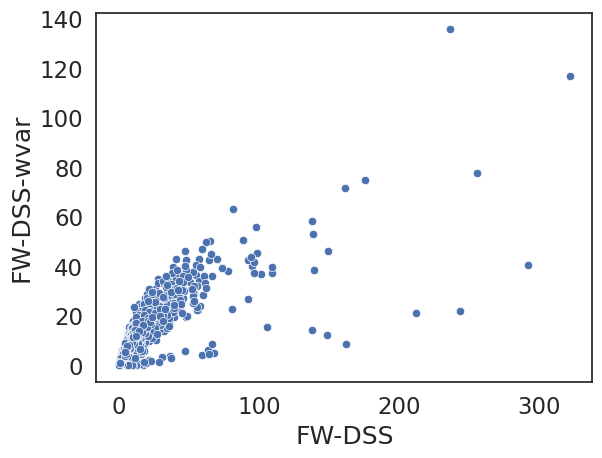

In [87]:
sns.scatterplot(x=albf_scores["FW-DSS"], y=albf_scores["FW-DSS-wvar"])
# get spearman correlation between FW-DSS and FW-DSS-wvar
spearman_corr = stats.spearmanr(albf_scores["FW-DSS"], albf_scores["FW-DSS-wvar"])
print(f"Spearman correlation between FW-DSS and FW-DSS-wvar: {spearman_corr}")

AUC for ALBF: 0.990723009860865
AUC for FW-DSS-wvar: 0.9806596362975563


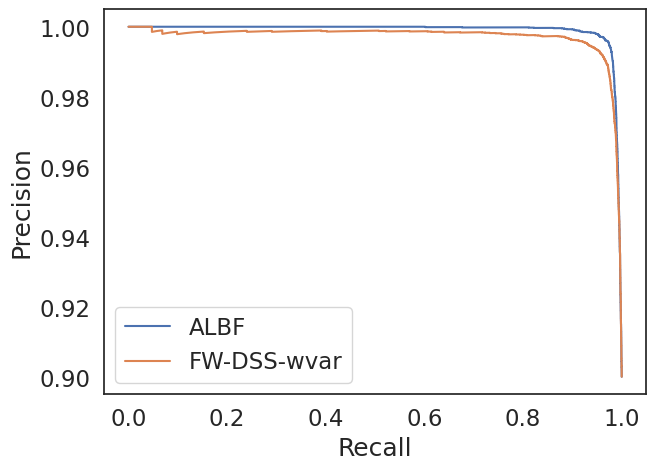

In [88]:
# which is better at separating positive and negative labels? ALBF or FW-FSS-wvar?
# calculate AUC for ALBF and FW-DSS-wvar
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve

auc_albf = roc_auc_score(albf_scores["true_label"], albf_scores["ALBF"])
auc_fw_dss = roc_auc_score(albf_scores["true_label"], albf_scores["FW-DSS-wvar"])

print(f"AUC for ALBF: {auc_albf}")
print(f"AUC for FW-DSS-wvar: {auc_fw_dss}")

# PR curve for ALBF and FW-DSS-wvar
# make true_label positive into 1 and negative into 0
albf_scores["true_label_binary"] = np.where(albf_scores["true_label"] == "positive", 1, 0)
pr_albf = precision_recall_curve(albf_scores["true_label_binary"], albf_scores["ALBF"])
pr_fw_dss = precision_recall_curve(albf_scores["true_label_binary"], albf_scores["FW-DSS-wvar"])

plt.figure(figsize=(7, 5))
plt.plot(pr_albf[1], pr_albf[0], label="ALBF")
plt.plot(pr_fw_dss[1], pr_fw_dss[0], label="FW-DSS-wvar")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

In [89]:
# FDR at 0.05 for ALBF and FW-DSS-wvar based on negative labels distribution of values at 95% quantile
fdr_albf = albf_scores[albf_scores["true_label"] == "negative"]["ALBF"].quantile(0.95)
fdr_fw_dss = albf_scores[albf_scores["true_label"] == "negative"]["FW-DSS-wvar"].quantile(0.95)

# How many junctions are above the FDR cutoffs for ALBF and FW-DSS-wvar?
albf_scores["fdr_albf"] = albf_scores["ALBF"] > fdr_albf
albf_scores["fdr_fw_dss"] = albf_scores["FW-DSS-wvar"] > fdr_fw_dss

# compare true labels with FDR labels
confusion_albf = pd.crosstab(albf_scores["true_label"], albf_scores["fdr_albf"])
confusion_fw_dss = pd.crosstab(albf_scores["true_label"], albf_scores["fdr_fw_dss"])

print(confusion_albf)
print(confusion_fw_dss)


fdr_albf    False  True 
true_label              
negative     1507     80
positive      340  13967
fdr_fw_dss  False  True 
true_label              
negative     1507     80
positive      828  13479


In [90]:
# whcih has better correlation with difference ?
# calcualte spearman 
spearman_corr = stats.spearmanr(albf_scores["ALBF"], albf_scores["difference"])
print(f"Spearman correlation between ALBF and simulated difference: {spearman_corr}")

spearman_corr = stats.spearmanr(albf_scores["FW-DSS-wvar"], albf_scores["difference"])
print(f"Spearman correlation between FW-DSS-wvar and simulated difference: {spearman_corr}")

Spearman correlation between ALBF and simulated difference: SignificanceResult(statistic=0.8205160427594392, pvalue=0.0)
Spearman correlation between FW-DSS-wvar and simulated difference: SignificanceResult(statistic=0.903942573192351, pvalue=0.0)
